# **Environment Setup**

In [1]:
# Install required packages
!pip install -q datasets
!pip install -q transformers
!pip install -q sentence-transformers

# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Set up hardware acceleration (GPU if available, else CPU)
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device selected: {device}")

Mounted at /content/drive
Device selected: cuda


# **Dataset Loading and Exploration**

In [2]:
from datasets import load_dataset

ds = load_dataset(
    "sapienzanlp-course-materials/hw-mnlp-2026"
)

# Define the strict subset of allowed features
ALLOWED_FEATURES = ['query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos']

# We need to look inside one split to get the actual data columns
all_columns = ds['train'].column_names

# Removing the unnecessary columns
columns_to_remove = [
    col for col in all_columns
    if col not in ALLOWED_FEATURES
]

dataset = ds.remove_columns(columns_to_remove)

# Sanity check: verify the remaining features
for split in dataset.keys():
    print(f"Split: {split:6} | Features: {dataset[split].column_names}")

# Unpack splits into dedicated variables for easier access
train = dataset['train']
test = dataset['test']
blind = dataset['blind']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

data/blind-00000-of-00001.parquet:   0%|          | 0.00/10.9M [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/66.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating blind split:   0%|          | 0/1322 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Split: test   | Features: ['query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos']
Split: blind  | Features: ['query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos']
Split: train  | Features: ['query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos']


# **Baseline Implementation**

## **Evaluation Function - (defined here to initially evaluate the baselines)**

In [3]:
def evaluation_function(model, dataset, correct_rankings=True):

  model.eval()

  rankings_cos = []
  correct_ranks_cos = []

  rankings_euc = []
  correct_ranks_euc = []

  with torch.no_grad():

    for i, (query, candidates) in enumerate(zip(dataset['query'], dataset['candidate_chunks'])):

        query_embedding = model.encode([query], convert_to_tensor=True)
        chunk_embeddings = model.encode(candidates, convert_to_tensor=True)

        cosine_similarities = torch.nn.functional.cosine_similarity(query_embedding, chunk_embeddings)
        ranking_cos = torch.argsort(cosine_similarities, descending=True).tolist()

        if correct_rankings:
          gold_pos_cos = dataset['answer_pos'][i]
          correct_rank_cos = ranking_cos.index(gold_pos_cos) + 1
          correct_ranks_cos.append(correct_rank_cos)

        rankings_cos.append(ranking_cos)

        euclidean_distances = torch.cdist(query_embedding, chunk_embeddings, p=2).squeeze(0)
        euclidean_similarity = 1 - euclidean_distances

        ranking_euc = torch.argsort(euclidean_distances, descending=False).tolist()

        if correct_rankings:
          gold_pos_euc = dataset['answer_pos'][i]
          correct_rank_euc = ranking_euc.index(gold_pos_euc) + 1
          correct_ranks_euc.append(correct_rank_euc)

        rankings_euc.append(ranking_euc)

  return rankings_cos, correct_ranks_cos, rankings_euc, correct_ranks_euc

## **Baseline: DistilBERT**

In [4]:
from sentence_transformers import models, SentenceTransformer
import torch

# Initialize the baseline model (Transformer + Mean Pooling)
word_embedding_model = models.Transformer('distilbert-base-uncased')
pooling_model = models.Pooling(word_embedding_model.get_embedding_dimension(), pooling_mode="mean")

model_distilbert = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)
model_distilbert.to(device)

distilBERT_rankings_cos, distilBERT_correct_ranks_cos, distilBERT_rankings_euclidean, distilBERT_correct_ranks_euclidean = evaluation_function(model_distilbert, test)

/tmp/ipykernel_580/1655437678.py:1: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import models, SentenceTransformer


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## **Baseline: all-MiniLM-L6-v2**

In [5]:
# Load the pre-trained MiniLM baseline
model_minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

minilm_rankings_cos, minilm_correct_ranks_cos, minilm_rankings_euclidean, minilm_correct_ranks_euclidean = evaluation_function(model_minilm, test)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## **Baseline: all-mpnet-base-v2**

In [ ]:
# Load the pre-trained mpnet baseline
model_mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=device)

mpnet_rankings_cos, mpnet_correct_ranks_cos, mpnet_rankings_euclidean, mpnet_correct_ranks_euclidean = evaluation_function(model_mpnet, test)

# **Baseline Evaluation**

## **Hit@k Metric**

In [7]:
def hit_at_k_metric(N, k, rankings):

  hits_count = 0
  for i in range(N):
    if rankings[i]<=k:
      hits_count += 1
  hit_at_k = hits_count/N

  return hit_at_k

## **Mean Reciprocal Rank (MRR)**

In [ ]:
def mrr_metric(rankings):
    sum_reciprocal_ranks = 0.0

    # Sum the reciprocal (1/x) of each correct answer's rank
    for rank in rankings:
        sum_reciprocal_ranks += (1.0 / rank)

    # Calculate the mean
    return sum_reciprocal_ranks / len(rankings)

## **all-MiniLM-L6-v2 Scores**

### **Cosine Similarity Results**

In [9]:
import pandas as pd

# Compute Hit@k metrics for k=1, 3, 5 (Cosine Similarity)
hit_at_1_minilm  = hit_at_k_metric(len(test), 1, minilm_correct_ranks_cos)
hit_at_3_minilm  = hit_at_k_metric(len(test), 3, minilm_correct_ranks_cos)
hit_at_5_minilm  = hit_at_k_metric(len(test), 5, minilm_correct_ranks_cos)

# Compute MMR metric (Cosine Similarity)
mrr_minilm_cos = mrr_metric(minilm_correct_ranks_cos)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5"],
    "My all-MiniLM Results (Cosine)": [hit_at_1_minilm, hit_at_3_minilm, hit_at_5_minilm],
    "Target Results": [0.4480, 0.7165, 0.8080]
}

data_mrr = {
    "Metric": ["MRR"],
    "My all-MiniLM MRR (Cosine)": [mrr_minilm_cos]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"My all-MiniLM Results (Cosine)": "{:.4f}", "Target Results": "{:.4f}"}))

df_mrr = pd.DataFrame(data_mrr)
display(df_mrr.style.hide(axis='index').format({"all-MiniLM MRR (Cosine)": "{:.4f}"}))

Metric,My all-MiniLM Results (Cosine),Target Results
Hit@1,0.4480,0.4480
Hit@3,0.7165,0.7165
Hit@5,0.8080,0.8080


Metric,My all-MiniLM MRR (Cosine)
MRR,0.609311


### **Euclidean Similarity Results**

In [10]:
# Compute Hit@k metrics for k=1, 3, 5 (Euclidean Distance)
hit_at_1_minilm_euc  = hit_at_k_metric(len(test), 1, minilm_correct_ranks_euclidean)
hit_at_3_minilm_euc  = hit_at_k_metric(len(test), 3, minilm_correct_ranks_euclidean)
hit_at_5_minilm_euc  = hit_at_k_metric(len(test), 5, minilm_correct_ranks_euclidean)

# Compute MMR metric (Euclidean Distance)
mrr_minilm_euc = mrr_metric(minilm_correct_ranks_euclidean)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5"],
    "My all-MiniLM Results (Euclidean)": [hit_at_1_minilm_euc, hit_at_3_minilm_euc, hit_at_5_minilm_euc]
}

data_mrr = {
    "Metric": ["MRR"],
    "My all-MiniLM MRR (Euclidean)": [mrr_minilm_euc]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"My all-MiniLM Results (Euclidean)": "{:.4f}"}))

df_mrr = pd.DataFrame(data_mrr)
display(df_mrr.style.hide(axis='index').format({"all-MiniLM MRR (Euclidean)": "{:.4f}"}))

Metric,My all-MiniLM Results (Euclidean)
Hit@1,0.4480
Hit@3,0.7165
Hit@5,0.8080


Metric,My all-MiniLM MRR (Euclidean)
MRR,0.609311


## **distilBERT Scores**

### **Cosine Similarity Results**

In [11]:
# Compute Hit@k metrics for k=1, 3, 5 (Cosine Similarity)
hit_at_1_distilBERT  = hit_at_k_metric(len(test), 1, distilBERT_correct_ranks_cos)
hit_at_3_distilBERT  = hit_at_k_metric(len(test), 3, distilBERT_correct_ranks_cos)
hit_at_5_distilBERT  = hit_at_k_metric(len(test), 5, distilBERT_correct_ranks_cos)

# Compute MMR metric (Cosine Similarity)
mrr_distilBERT_cos = mrr_metric(distilBERT_correct_ranks_cos)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5"],
    "My distilBERT Results (Cosine)": [hit_at_1_distilBERT, hit_at_3_distilBERT, hit_at_5_distilBERT],
    "Target Results": [0.1765, 0.4435, 0.6045]
}

data_mrr = {
    "Metric": ["MRR"],
    "distilBERT MRR (Cosine)": [mrr_distilBERT_cos]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"My distilBERT Results (Cosine)": "{:.4f}", "Target Results": "{:.4f}"}))

df_mrr = pd.DataFrame(data_mrr)
display(df_mrr.style.hide(axis='index').format({"distilBERT MRR (Cosine)": "{:.4f}"}))

Metric,My distilBERT Results (Cosine),Target Results
Hit@1,0.1765,0.1765
Hit@3,0.4435,0.4435
Hit@5,0.6045,0.6045


Metric,distilBERT MRR (Cosine)
MRR,0.3657


### **Euclidean Similarity Results**

In [12]:

# Compute Hit@k metrics for k=1, 3, 5 (Euclidean Distance)
hit_at_1_distilBERT_euc  = hit_at_k_metric(len(test), 1, distilBERT_correct_ranks_euclidean)
hit_at_3_distilBERT_euc  = hit_at_k_metric(len(test), 3, distilBERT_correct_ranks_euclidean)
hit_at_5_distilBERT_euc  = hit_at_k_metric(len(test), 5, distilBERT_correct_ranks_euclidean)

# Compute MMR metric (Euclidean Distance)
mrr_distilBERT_euc = mrr_metric(distilBERT_correct_ranks_euclidean)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5"],
    "My distilBERT Results (Euclidean)": [hit_at_1_distilBERT_euc, hit_at_3_distilBERT_euc, hit_at_5_distilBERT_euc]
}

data_mrr = {
    "Metric": ["MRR"],
    "distilBERT MRR (Euclidean)": [mrr_distilBERT_euc]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"My distilBERT Results (Euclidean)": "{:.4f}", "Target Results": "{:.4f}"}))

df_mrr = pd.DataFrame(data_mrr)
display(df_mrr.style.hide(axis='index').format({"distilBERT MRR (Euclidean)": "{:.4f}"}))

Metric,My distilBERT Results (Euclidean)
Hit@1,0.1650
Hit@3,0.4150
Hit@5,0.5810


Metric,distilBERT MRR (Euclidean)
MRR,0.3488


## **all-mpnet-base-v2 Scores**

### **Cosine Similarity Results**

In [13]:

# Compute Hit@k metrics for k=1, 3, 5 (Cosine Similarity)
hit_at_1_mpnet  = hit_at_k_metric(len(test), 1, mpnet_correct_ranks_cos)
hit_at_3_mpnet  = hit_at_k_metric(len(test), 3, mpnet_correct_ranks_cos)
hit_at_5_mpnet  = hit_at_k_metric(len(test), 5, mpnet_correct_ranks_cos)

# Compute MMR metric (Cosine Similarity)
mrr_mpnet_cos = mrr_metric(mpnet_correct_ranks_cos)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5"],
    "My all-mpnet Results (Cosine)": [hit_at_1_mpnet, hit_at_3_mpnet, hit_at_5_mpnet]
}

data_mrr = {
    "Metric": ["MRR"],
    "My all-mpnet MRR (Cosine)": [mrr_mpnet_cos]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"My all-mpnet Results (Cosine)": "{:.4f}"}))

df_mrr = pd.DataFrame(data_mrr)
display(df_mrr.style.hide(axis='index').format({"all-mpnet MRR (Cosine)": "{:.4f}"}))

Metric,My all-mpnet Results (Cosine)
Hit@1,0.5110
Hit@3,0.7650
Hit@5,0.8540


Metric,My all-mpnet MRR (Cosine)
MRR,0.661055


### **Euclidean Similarity Results**

In [14]:
# Compute Hit@k metrics for k=1, 3, 5 (Euclidean Distance)
hit_at_1_mpnet_euc  = hit_at_k_metric(len(test), 1, mpnet_correct_ranks_euclidean)
hit_at_3_mpnet_euc  = hit_at_k_metric(len(test), 3, mpnet_correct_ranks_euclidean)
hit_at_5_mpnet_euc  = hit_at_k_metric(len(test), 5, mpnet_correct_ranks_euclidean)

# Compute MMR metric (Euclidean Distance)
mrr_mpnet_euc = mrr_metric(mpnet_correct_ranks_euclidean)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5"],
    "My all-mpnet Results (Euclidean)": [hit_at_1_mpnet_euc, hit_at_3_mpnet_euc, hit_at_5_mpnet_euc]
}

data_mrr = {
    "Metric": ["MRR"],
    "My all-mpnet MRR (Euclidean)": [mrr_mpnet_euc]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"My all-mpnet Results (Euclidean)": "{:.4f}"}))

df_mrr = pd.DataFrame(data_mrr)
display(df_mrr.style.hide(axis='index').format({"all-mpnet MRR (Euclidean)": "{:.4f}"}))

Metric,My all-mpnet Results (Euclidean)
Hit@1,0.5110
Hit@3,0.7650
Hit@5,0.8540


Metric,My all-mpnet MRR (Euclidean)
MRR,0.661055


# **Fine Tuning**

## **Contrastive InfoNCE style**

In [ ]:
from sklearn.model_selection import train_test_split
from sentence_transformers import (
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    SentenceTransformerModelCardData,
)
from datasets import Dataset
from sentence_transformers.sentence_transformer.losses import MultipleNegativesRankingLoss
from sentence_transformers.sentence_transformer.training_args import BatchSamplers
from sentence_transformers.sentence_transformer.evaluation import InformationRetrievalEvaluator
from transformers import EarlyStoppingCallback
import random

# Train/Validation Split
train_indices, dev_indices = train_test_split(
    range(len(train)),
    test_size=0.2,
    random_state=42,
    shuffle=True
)
train_subset = train.select(train_indices)
dev_subset = train.select(dev_indices)

# This is not necessary but coherent with the model below
word_embedding_model_clean_contrastive = models.Transformer('distilbert-base-uncased')
# We leave this here just to be free of changing in any time the pooling strategy
pooling_model_clean_contrastive = models.Pooling(word_embedding_model_clean_contrastive.get_embedding_dimension(), pooling_mode="mean")

contrastive_fineTuned = SentenceTransformer(modules=[word_embedding_model_clean_contrastive, pooling_model_clean_contrastive], device=device)
contrastive_fineTuned.to(device)

# Loss function definition
loss = MultipleNegativesRankingLoss(contrastive_fineTuned)

# Preparing the Negatives
negatives = []

# Fixed seed
rng = random.Random(69)

for row in train_subset:
    candidates = row['candidate_chunks']
    pos = row['answer_pos']

    # Filter out the correct answer and pick a random wrong candidate
    neg_candidates = []
    for i, c in enumerate(candidates):
        if i != pos:
            neg_candidates.append(c)

    neg = rng.choice(neg_candidates)
    negatives.append(neg)

# Training dataset creation
train_dataset = Dataset.from_dict({
    "anchor": train_subset['query'],
    "positive": train_subset['answer'],
    "negative": negatives
})

# Defining Training Arguments
args = SentenceTransformerTrainingArguments(
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    warmup_steps=300,
    fp16=True,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="epoch",
    # eval_steps=500,
    save_strategy="epoch",
    # save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="eval_dev-eval_cosine_recall@10",
)

# Configure Information Retrieval Evaluator for the Dev Set
queries = {}
corpus = {}
relevant_docs = {}

for i in range(len(dev_subset)):
    qid = dev_subset['query_id'][i]
    query = dev_subset['query'][i]
    candidates = dev_subset['candidate_chunks'][i]
    gold_pos = dev_subset['answer_pos'][i]

    queries[qid] = query

    for j, candidate in enumerate(candidates):
        # Generating the candidate id
        candidate_id = f"{qid}_{j}"
        corpus[candidate_id] = candidate

        if j == gold_pos:
            relevant_docs.setdefault(qid, set()).add(candidate_id)

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="dev-eval"
)

trainer = SentenceTransformerTrainer(
    model=contrastive_fineTuned,
    args=args,
    train_dataset=train_dataset,
    # eval_dataset=dev_subset,
    loss=loss,
    evaluator= evaluator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Epoch,Training Loss,Validation Loss,Dev-eval Cosine Accuracy@1,Dev-eval Cosine Accuracy@3,Dev-eval Cosine Accuracy@5,Dev-eval Cosine Accuracy@10,Dev-eval Cosine Precision@1,Dev-eval Cosine Precision@3,Dev-eval Cosine Precision@5,Dev-eval Cosine Precision@10,Dev-eval Cosine Recall@1,Dev-eval Cosine Recall@3,Dev-eval Cosine Recall@5,Dev-eval Cosine Recall@10,Dev-eval Cosine Ndcg@10,Dev-eval Cosine Mrr@10,Dev-eval Cosine Map@100
1,No log,No log,0.348125,0.572500,0.656250,0.751250,0.348125,0.190833,0.131250,0.075125,0.348125,0.572500,0.656250,0.751250,0.545558,0.480150,0.487085
2,No log,No log,0.388125,0.616875,0.693750,0.777500,0.388125,0.205625,0.138750,0.077750,0.388125,0.616875,0.693750,0.777500,0.580050,0.517094,0.523490
3,0.503681,No log,0.406250,0.629375,0.703125,0.788750,0.406250,0.209792,0.140625,0.078875,0.406250,0.629375,0.703125,0.788750,0.594956,0.533045,0.539719
4,0.503681,No log,0.416875,0.633125,0.704375,0.788125,0.416875,0.211042,0.140875,0.078812,0.416875,0.633125,0.704375,0.788125,0.600861,0.541022,0.547563
5,0.041367,No log,0.439375,0.646250,0.711250,0.785625,0.439375,0.215417,0.142250,0.078562,0.439375,0.646250,0.711250,0.785625,0.610581,0.554618,0.561490
6,0.041367,No log,0.420000,0.630000,0.712500,0.786875,0.420000,0.210000,0.142500,0.078687,0.420000,0.630000,0.712500,0.786875,0.602018,0.542860,0.549717


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TrainOutput(global_step=1200, training_loss=0.22908535460631052, metrics={'train_runtime': 964.0163, 'train_samples_per_second': 132.778, 'train_steps_per_second': 4.149, 'total_flos': 0.0, 'train_loss': 0.22908535460631052, 'epoch': 6.0})

### **Dev Evaluation**

In [ ]:
# Evaluate the Fine-Tuned Model (We do this just to have an idea of the hit@k metric on the candidate chunks)
_ , contrastive_fineTuned_correct_ranks_cos, _ , contrastive_fineTuned_correct_ranks_euc = evaluation_function(contrastive_fineTuned, dev_subset)

# Calculate Metrics and Display Results (Cosine Similarity)
hit_at_1_fineTuned_contrastive_cos = hit_at_k_metric(len(dev_subset), 1, contrastive_fineTuned_correct_ranks_cos)
hit_at_3_fineTuned_contrastive_cos = hit_at_k_metric(len(dev_subset), 3, contrastive_fineTuned_correct_ranks_cos)
hit_at_5_fineTuned_contrastive_cos = hit_at_k_metric(len(dev_subset), 5, contrastive_fineTuned_correct_ranks_cos)

mrr_fineTuned_contrastive_cos = mrr_metric(contrastive_fineTuned_correct_ranks_cos)

# Calculate Metrics and Display Results (Euclidean Distance)
hit_at_1_fineTuned_contrastive_euc = hit_at_k_metric(len(dev_subset), 1, contrastive_fineTuned_correct_ranks_euc)
hit_at_3_fineTuned_contrastive_euc = hit_at_k_metric(len(dev_subset), 3, contrastive_fineTuned_correct_ranks_euc)
hit_at_5_fineTuned_contrastive_euc = hit_at_k_metric(len(dev_subset), 5, contrastive_fineTuned_correct_ranks_euc)

mrr_fineTuned_contrastive_euc = mrr_metric(contrastive_fineTuned_correct_ranks_euc)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5", "MRR"],
    "distilBERT dev Results (Contrastive InfoNCE) Cosine Similarity": [hit_at_1_fineTuned_contrastive_cos, hit_at_3_fineTuned_contrastive_cos, hit_at_5_fineTuned_contrastive_cos, mrr_fineTuned_contrastive_cos],
    "distilBERT dev Results (Contrastive InfoNCE) Euclidean Distance": [hit_at_1_fineTuned_contrastive_euc, hit_at_3_fineTuned_contrastive_euc, hit_at_5_fineTuned_contrastive_euc, mrr_fineTuned_contrastive_euc]

}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"distilBERT dev Results (Contrastive InfoNCE) Cosine Similarity": "{:.4f}", "distilBERT dev Results (Contrastive InfoNCE) Euclidean Distance": "{:.4f}"}))


Metric,distilBERT dev Results (Contrastive InfoNCE) Cosine Similarity,distilBERT dev Results (Contrastive InfoNCE) Euclidean Distance
Hit@1,0.5062,0.4944
Hit@3,0.7850,0.7669
Hit@5,0.8681,0.8569
MRR,0.6633,0.6512


## **SentenceTriplet**

In [ ]:
from sentence_transformers.sentence_transformer.losses import TripletLoss, TripletDistanceMetric

# Reload distilBERT to have fresh parameters
word_embedding_model_clean_triplet = models.Transformer('distilbert-base-uncased')
pooling_model_clean_triplet = models.Pooling(word_embedding_model_clean_triplet.get_embedding_dimension(), pooling_mode="mean")

triplet_fineTuned = SentenceTransformer(modules=[word_embedding_model_clean_triplet, pooling_model_clean_triplet], device=device)
triplet_fineTuned.to(device)

# Loss function definition
loss = TripletLoss(
    model=triplet_fineTuned,
    distance_metric= TripletDistanceMetric.COSINE,
    triplet_margin=0.2
)

# Defining Training Arguments
args = SentenceTransformerTrainingArguments(
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    warmup_steps=300,
    fp16=True,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_dev-eval_cosine_recall@10",
)

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="dev-eval"
)

trainer = SentenceTransformerTrainer(
    model=triplet_fineTuned,
    args=args,
    train_dataset=train_dataset,
    loss=loss,
    evaluator=evaluator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Epoch,Training Loss,Validation Loss,Dev-eval Cosine Accuracy@1,Dev-eval Cosine Accuracy@3,Dev-eval Cosine Accuracy@5,Dev-eval Cosine Accuracy@10,Dev-eval Cosine Precision@1,Dev-eval Cosine Precision@3,Dev-eval Cosine Precision@5,Dev-eval Cosine Precision@10,Dev-eval Cosine Recall@1,Dev-eval Cosine Recall@3,Dev-eval Cosine Recall@5,Dev-eval Cosine Recall@10,Dev-eval Cosine Ndcg@10,Dev-eval Cosine Mrr@10,Dev-eval Cosine Map@100
1,No log,No log,0.187500,0.306875,0.365000,0.440000,0.187500,0.102292,0.073000,0.044000,0.187500,0.306875,0.365000,0.440000,0.305317,0.263305,0.272682
2,No log,No log,0.204375,0.323750,0.379375,0.461250,0.204375,0.107917,0.075875,0.046125,0.204375,0.323750,0.379375,0.461250,0.324359,0.281620,0.291813
3,0.052368,No log,0.203750,0.318125,0.372500,0.452500,0.203750,0.106042,0.074500,0.045250,0.203750,0.318125,0.372500,0.452500,0.318302,0.276551,0.286434
4,0.052368,No log,0.192500,0.305000,0.363750,0.445625,0.192500,0.101667,0.072750,0.044562,0.192500,0.305000,0.363750,0.445625,0.308496,0.265898,0.275387
5,0.003943,No log,0.170625,0.271250,0.335000,0.398750,0.170625,0.090417,0.067000,0.039875,0.170625,0.271250,0.335000,0.398750,0.276442,0.238212,0.247649


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.02815510857105255, metrics={'train_runtime': 791.825, 'train_samples_per_second': 161.652, 'train_steps_per_second': 5.052, 'total_flos': 0.0, 'train_loss': 0.02815510857105255, 'epoch': 5.0})

### **Dev Evaluation**

In [ ]:
# Evaluate the Fine-Tuned Model (We do this just to have an idea of the hit@k metric on the candidate chunks)
_ , triplet_fineTuned_correct_ranks_cos, _ , triplet_fineTuned_correct_ranks_euc = evaluation_function(triplet_fineTuned, dev_subset)

# Calculate Metrics and Display Results (Cosine Similarity)
hit_at_1_fineTuned_triplet_cos = hit_at_k_metric(len(dev_subset), 1, triplet_fineTuned_correct_ranks_cos)
hit_at_3_fineTuned_triplet_cos = hit_at_k_metric(len(dev_subset), 3, triplet_fineTuned_correct_ranks_cos)
hit_at_5_fineTuned_triplet_cos = hit_at_k_metric(len(dev_subset), 5, triplet_fineTuned_correct_ranks_cos)

mrr_fineTuned_triplet_cos = mrr_metric(triplet_fineTuned_correct_ranks_cos)

# Calculate Metrics and Display Results (Euclidean Distance)
hit_at_1_fineTuned_triplet_euc = hit_at_k_metric(len(dev_subset), 1, triplet_fineTuned_correct_ranks_euc)
hit_at_3_fineTuned_triplet_euc = hit_at_k_metric(len(dev_subset), 3, triplet_fineTuned_correct_ranks_euc)
hit_at_5_fineTuned_triplet_euc = hit_at_k_metric(len(dev_subset), 5, triplet_fineTuned_correct_ranks_euc)

mrr_fineTuned_triplet_euc = mrr_metric(triplet_fineTuned_correct_ranks_euc)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5", "MRR"],
    "distilBERT dev Results (TripletLoss) Cosine Similarity": [hit_at_1_fineTuned_triplet_cos, hit_at_3_fineTuned_triplet_cos, hit_at_5_fineTuned_triplet_cos, mrr_fineTuned_triplet_cos],
    "distilBERT dev Results (TripletLoss) Euclidean Distance": [hit_at_1_fineTuned_triplet_euc, hit_at_3_fineTuned_triplet_euc, hit_at_5_fineTuned_triplet_euc, mrr_fineTuned_triplet_euc]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"distilBERT dev Results (TripletLoss) Cosine Similarity": "{:.4f}", "distilBERT dev Results (TripletLoss) Euclidean Distance": "{:.4f}"}))


Metric,distilBERT dev Results (TripletLoss) Cosine Similarity,distilBERT dev Results (TripletLoss) Euclidean Distance
Hit@1,0.5787,0.5706
Hit@3,0.7969,0.7894
Hit@5,0.8781,0.8788
MRR,0.7073,0.7014


# **Evaluation**

## **Test**

### **Cosine Similarity Results**

In [ ]:
# CONTRASTIVE INFONCE
contrastive_fineTuned_rankings_cos, contrastive_fineTuned_correct_ranks_cos, contrastive_fineTuned_rankings_euc, contrastive_fineTuned_correct_ranks_euc= evaluation_function(contrastive_fineTuned, test)

# InfoNCE (Cosine) Metrics
hit_at_1_contrastive_test_cos  = hit_at_k_metric(len(test), 1, contrastive_fineTuned_correct_ranks_cos)
hit_at_3_contrastive_test_cos  = hit_at_k_metric(len(test), 3, contrastive_fineTuned_correct_ranks_cos)
hit_at_5_contrastive_test_cos  = hit_at_k_metric(len(test), 5, contrastive_fineTuned_correct_ranks_cos)

mrr_contrastive_test_cos = mrr_metric(contrastive_fineTuned_correct_ranks_cos)

# SENTENCE TRIPLET
triplet_fineTuned_rankings_cos, triplet_fineTuned_correct_ranks_cos, triplet_fineTuned_rankings_euc, triplet_fineTuned_correct_ranks_euc = evaluation_function(triplet_fineTuned, test)

# Triplets (Cosine) Metrics
hit_at_1_triplet_test_cos  = hit_at_k_metric(len(test), 1, triplet_fineTuned_correct_ranks_cos)
hit_at_3_triplet_test_cos  = hit_at_k_metric(len(test), 3, triplet_fineTuned_correct_ranks_cos)
hit_at_5_triplet_test_cos  = hit_at_k_metric(len(test), 5, triplet_fineTuned_correct_ranks_cos)

mrr_triplet_test_cos = mrr_metric(triplet_fineTuned_correct_ranks_cos)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5", "MRR"],
    "distilBERT test Results (Contrastive InfoNCE) (Cosine)": [hit_at_1_contrastive_test_cos, hit_at_3_contrastive_test_cos, hit_at_5_contrastive_test_cos, mrr_contrastive_test_cos],
    "distilBERT test Results (TripletLoss) (Cosine)": [hit_at_1_triplet_test_cos, hit_at_3_triplet_test_cos, hit_at_5_triplet_test_cos, mrr_triplet_test_cos],
    "distilBERT Results (Baseline) (Cosine)": [hit_at_1_distilBERT, hit_at_3_distilBERT, hit_at_5_distilBERT, mrr_distilBERT_cos],
    "all-MiniLM Results (Baseline) (Cosine)": [hit_at_1_minilm, hit_at_3_minilm, hit_at_5_minilm, mrr_minilm_cos],
    "all-mpnet Results (Baseline) (Cosine)": [hit_at_1_mpnet, hit_at_3_mpnet, hit_at_5_mpnet, mrr_mpnet_cos]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"distilBERT test Results (Contrastive InfoNCE) (Cosine)": "{:.4f}", "distilBERT test Results (TripletLoss) (Cosine)": "{:.4f}", "distilBERT Results (Baseline) (Cosine)": "{:.4f}",  "all-MiniLM Results (Baseline) (Cosine)": "{:.4f}", "all-mpnet Results (Baseline) (Cosine)": "{:.4f}"}))

Metric,distilBERT test Results (Contrastive InfoNCE) (Cosine),distilBERT test Results (TripletLoss) (Cosine),distilBERT Results (Baseline) (Cosine),all-MiniLM Results (Baseline) (Cosine),all-mpnet Results (Baseline) (Cosine)
Hit@1,0.5340,0.5835,0.1765,0.4480,0.5110
Hit@3,0.7865,0.8040,0.4435,0.7165,0.7650
Hit@5,0.8760,0.8790,0.6045,0.8080,0.8540
MRR,0.6787,0.7128,0.3657,0.6093,0.6611


### **Euclidean Similarity Results**

In [ ]:

# InfoNCE (Euclidean) Metrics
hit_at_1_contrastive_test_euc  = hit_at_k_metric(len(test), 1, contrastive_fineTuned_correct_ranks_euc)
hit_at_3_contrastive_test_euc  = hit_at_k_metric(len(test), 3, contrastive_fineTuned_correct_ranks_euc)
hit_at_5_contrastive_test_euc  = hit_at_k_metric(len(test), 5, contrastive_fineTuned_correct_ranks_euc)

mrr_contrastive_test_euc = mrr_metric(contrastive_fineTuned_correct_ranks_euc)

# Triplets (Euclidean) Metrics
hit_at_1_triplet_test_euc  = hit_at_k_metric(len(test), 1, triplet_fineTuned_correct_ranks_euc)
hit_at_3_triplet_test_euc  = hit_at_k_metric(len(test), 3, triplet_fineTuned_correct_ranks_euc)
hit_at_5_triplet_test_euc  = hit_at_k_metric(len(test), 5, triplet_fineTuned_correct_ranks_euc)

mrr_triplet_test_euc = mrr_metric(triplet_fineTuned_correct_ranks_euc)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5", "MRR"],
    "distilBERT test Results (Contrastive InfoNCE) (Euclidean)": [hit_at_1_contrastive_test_euc, hit_at_3_contrastive_test_euc, hit_at_5_contrastive_test_euc, mrr_contrastive_test_euc],
    "distilBERT test Results (TripletLoss) (Euclidean)": [hit_at_1_triplet_test_euc, hit_at_3_triplet_test_euc, hit_at_5_triplet_test_euc, mrr_triplet_test_euc],
    "distilBERT Results (Baseline) (Euclidean)": [hit_at_1_distilBERT_euc, hit_at_3_distilBERT_euc, hit_at_5_distilBERT_euc, mrr_distilBERT_euc],
    "all-MiniLM Results (Baseline) (Euclidean)": [hit_at_1_minilm_euc, hit_at_3_minilm_euc, hit_at_5_minilm_euc, mrr_minilm_euc],
    "all-mpnet Results (Baseline) (Euclidean)": [hit_at_1_mpnet_euc, hit_at_3_mpnet_euc, hit_at_5_mpnet_euc, mrr_mpnet_euc]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"distilBERT test Results (Contrastive InfoNCE) (Euclidean)": "{:.4f}", "distilBERT test Results (TripletLoss) (Euclidean)": "{:.4f}", "distilBERT Results (Baseline) (Euclidean)": "{:.4f}", "all-MiniLM Results (Baseline) (Euclidean)": "{:.4f}", "all-mpnet Results (Baseline) (Euclidean)": "{:.4f}"}))

Metric,distilBERT test Results (Contrastive InfoNCE) (Euclidean),distilBERT test Results (TripletLoss) (Euclidean),distilBERT Results (Baseline) (Euclidean),all-MiniLM Results (Baseline) (Euclidean),all-mpnet Results (Baseline) (Euclidean)
Hit@1,0.5135,0.5770,0.1650,0.4480,0.5110
Hit@3,0.7700,0.7965,0.4150,0.7165,0.7650
Hit@5,0.8615,0.8790,0.5810,0.8080,0.8540
MRR,0.6633,0.7062,0.3488,0.6093,0.6611


## **Blind Rankings**

In [ ]:
# DISTILBERT BASE
distilBERT_rankings_cos_blind, _ , distilBERT_rankings_euc_blind, _ = evaluation_function(model_distilbert, blind, correct_rankings=False)
print("✅ DistilBERT complete.\n")

# ALL-MINILM
minilm_rankings_cos_blind, _ , minilm_rankings_euc_blind, _ = evaluation_function(model_minilm, blind, correct_rankings=False)
print("✅ MiniLM complete.\n")

# ALL-MPNET
mpnet_rankings_cos_blind, _ , mpnet_rankings_euc_blind, _ = evaluation_function(model_mpnet, blind, correct_rankings=False)
print("✅ mpnet complete.\n")

# CONTRASTIVE INFONCE
contrastive_fineTuned_rankings_cos_blind, _ , contrastive_fineTuned_rankings_euc_blind, _ = evaluation_function(contrastive_fineTuned, blind, correct_rankings=False)
print("✅ Contrastive complete.\n")

# SENTENCE TRIPLET
triplet_fineTuned_rankings_cos_blind, _ , triplet_fineTuned_rankings_euc_blind, _  = evaluation_function(triplet_fineTuned, blind, correct_rankings=False)
print("✅ Triplet complete.\n")

✅ DistilBERT complete.

✅ MiniLM complete.

✅ mpnet complete.

✅ Contrastive complete.

✅ Triplet complete.



# **JSON File Creation**

In [ ]:
import os
import json

output_folder = '/content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

def save_jsonl(ids, rankings, filename, folder):

    filename = os.path.join(folder, filename)
    with open(filename, 'w', encoding='utf-8') as f:
        for q_id, ranking in zip(ids, rankings):
            json.dump({str(q_id): ranking}, f)
            f.write('\n')
    print(f"File saved: {filename}")

# Cosine Similarity file saving
tasks_cosine = [
    (test['query_id'], distilBERT_rankings_cos, "hit_k_1-test-distilbert-base-cosine.jsonl"),
    (blind['query_id'], distilBERT_rankings_cos_blind, "hit_k_1-blind-distilbert-base-cosine.jsonl"),
    (test['query_id'], minilm_rankings_cos, "hit_k_1-test-AllMini-base-cosine.jsonl"),
    (blind['query_id'], minilm_rankings_cos_blind, "hit_k_1-blind-AllMini-base-cosine.jsonl"),
    (test['query_id'], mpnet_rankings_cos, "hit_k_1-test-mpnet-base-cosine.jsonl"),
    (blind['query_id'], mpnet_rankings_cos_blind, "hit_k_1-blind-mpnet-base-cosine.jsonl"),
    (test['query_id'], contrastive_fineTuned_rankings_cos, "hit_k_1-test-distilbert-contrastive-cosine.jsonl"),
    (blind['query_id'], contrastive_fineTuned_rankings_cos_blind, "hit_k_1-blind-distilbert-contrastive-cosine.jsonl"),
    (test['query_id'], triplet_fineTuned_rankings_cos, "hit_k_1-test-distilbert-triplet-cosine.jsonl"),
    (blind['query_id'], triplet_fineTuned_rankings_cos_blind, "hit_k_1-blind-distilbert-triplet-cosine.jsonl"),
]

for ids, rankings, name in tasks_cosine:
    save_jsonl(ids, rankings, name, output_folder)

# Euclidean Similarity file saving
tasks_euclidean = [
    (test['query_id'], distilBERT_rankings_euclidean, "hit_k_1-test-distilbert-base-euclidean.jsonl"),
    (blind['query_id'], distilBERT_rankings_euc_blind, "hit_k_1-blind-distilbert-base-euclidean.jsonl"),
    (test['query_id'], minilm_rankings_euclidean, "hit_k_1-test-AllMini-base-euclidean.jsonl"),
    (blind['query_id'], minilm_rankings_euc_blind, "hit_k_1-blind-AllMini-base-euclidean.jsonl"),
    (test['query_id'], mpnet_rankings_euclidean, "hit_k_1-test-mpnet-base-euclidean.jsonl"),
    (blind['query_id'], mpnet_rankings_euc_blind, "hit_k_1-blind-mpnet-base-euclidean.jsonl"),
    (test['query_id'], contrastive_fineTuned_rankings_euc, "hit_k_1-test-distilbert-contrastive-euclidean.jsonl"),
    (blind['query_id'], contrastive_fineTuned_rankings_euc_blind, "hit_k_1-blind-distilbert-contrastive-euclidean.jsonl"),
    (test['query_id'], triplet_fineTuned_rankings_euc, "hit_k_1-test-distilbert-triplet-euclidean.jsonl"),
    (blind['query_id'], triplet_fineTuned_rankings_euc_blind, "hit_k_1-blind-distilbert-triplet-euclidean.jsonl"),
]

for ids, rankings, name in tasks_euclidean:
    save_jsonl(ids, rankings, name, output_folder)

File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-distilbert-base-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-distilbert-base-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-AllMini-base-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-AllMini-base-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-mpnet-base-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-mpnet-base-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-distilbert-contrastive-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-distilbert-contrastive-cosine.jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k

# **Plots Area**

## **Hit@k Comparison**

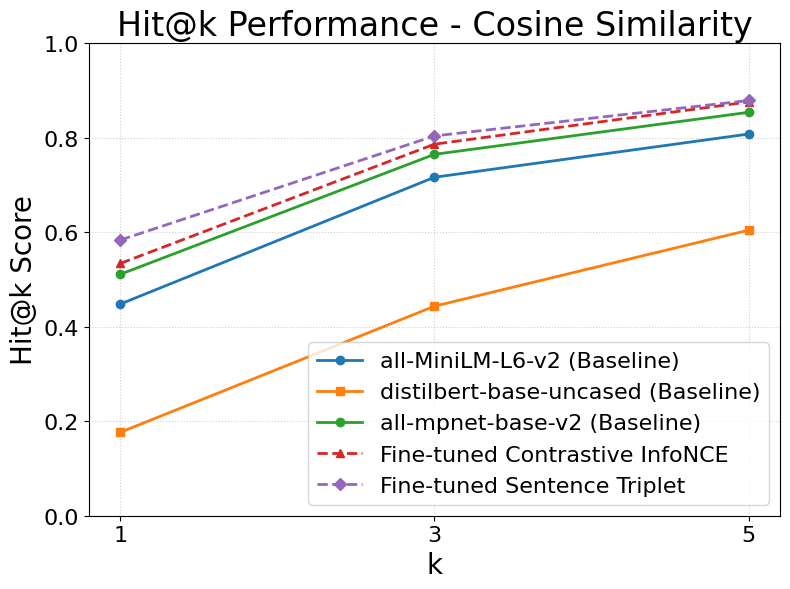

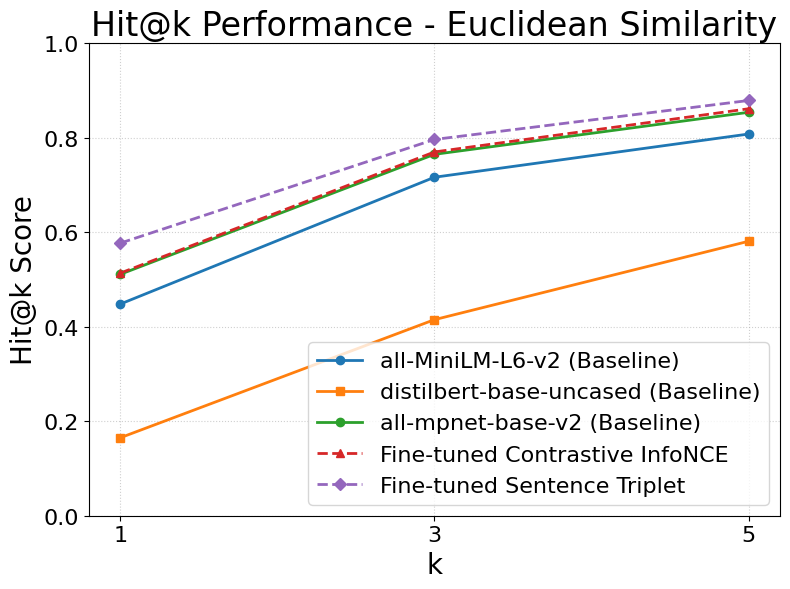

In [ ]:
import matplotlib.pyplot as plt

plots_folder = '/content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/plots/'

if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)

# Values for k-axis
k_values = [1, 3, 5]

# --- (COSINE SIMILARITY) ---
# Baselines
y_minilm_cos = [hit_at_1_minilm, hit_at_3_minilm, hit_at_5_minilm]
y_distil_cos = [hit_at_1_distilBERT, hit_at_3_distilBERT, hit_at_5_distilBERT]
y_mpnet_cos = [hit_at_1_mpnet, hit_at_3_mpnet, hit_at_5_mpnet]

# Fine-tuned
y_contrastive_cos = [hit_at_1_contrastive_test_cos, hit_at_3_contrastive_test_cos, hit_at_5_contrastive_test_cos]
y_triplet_cos = [hit_at_1_triplet_test_cos, hit_at_3_triplet_test_cos, hit_at_5_triplet_test_cos]

# --- (EUCLIDEAN SIMILARITY) ---
# Baselines
y_minilm_euc = [hit_at_1_minilm_euc, hit_at_3_minilm_euc, hit_at_5_minilm_euc]
y_distil_euc = [hit_at_1_distilBERT_euc, hit_at_3_distilBERT_euc, hit_at_5_distilBERT_euc]
y_mpnet_euc = [hit_at_1_mpnet_euc, hit_at_3_mpnet_euc, hit_at_5_mpnet_euc]

# Fine-tuned
y_contrastive_euc = [hit_at_1_contrastive_test_euc, hit_at_3_contrastive_test_euc, hit_at_5_contrastive_test_euc]
y_triplet_euc = [hit_at_1_triplet_test_euc, hit_at_3_triplet_test_euc, hit_at_5_triplet_test_euc]

# --- PLOT 1: COSINE SIMILARITY ---
fig1, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_values, y_minilm_cos, marker='o', linestyle='-', linewidth=2, label='all-MiniLM-L6-v2 (Baseline)')
ax1.plot(k_values, y_distil_cos, marker='s', linestyle='-', linewidth=2, label='distilbert-base-uncased (Baseline)')
ax1.plot(k_values, y_mpnet_cos, marker='o', linestyle='-', linewidth=2, label='all-mpnet-base-v2 (Baseline)')
ax1.plot(k_values, y_contrastive_cos, marker='^', linestyle='--', linewidth=2, label='Fine-tuned Contrastive InfoNCE')
ax1.plot(k_values, y_triplet_cos, marker='D', linestyle='--', linewidth=2, label='Fine-tuned Sentence Triplet')

ax1.set_title('Hit@k Performance - Cosine Similarity', fontsize=24)
ax1.set_xlabel('k', fontsize=20)
ax1.set_ylabel('Hit@k Score', fontsize=20)
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1.0)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=16)

ax1.tick_params(axis='both', which='major', labelsize=16)
fig1.tight_layout()
fig1.savefig(plots_folder + 'hit_at_k_cosine.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- PLOT 2: EUCLIDEAN SIMILARITY ---
fig2, ax2 = plt.subplots(figsize=(8, 6))

ax2.plot(k_values, y_minilm_euc, marker='o', linestyle='-', linewidth=2, label='all-MiniLM-L6-v2 (Baseline)')
ax2.plot(k_values, y_distil_euc, marker='s', linestyle='-', linewidth=2, label='distilbert-base-uncased (Baseline)')
ax2.plot(k_values, y_mpnet_euc, marker='o', linestyle='-', linewidth=2, label='all-mpnet-base-v2 (Baseline)')
ax2.plot(k_values, y_contrastive_euc, marker='^', linestyle='--', linewidth=2, label='Fine-tuned Contrastive InfoNCE')
ax2.plot(k_values, y_triplet_euc, marker='D', linestyle='--', linewidth=2, label='Fine-tuned Sentence Triplet')

ax2.set_title('Hit@k Performance - Euclidean Similarity', fontsize=24)
ax2.set_xlabel('k', fontsize=20)
ax2.set_ylabel('Hit@k Score', fontsize=20)
ax2.set_xticks(k_values)
ax2.set_ylim(0, 1.0)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=16)

ax2.tick_params(axis='both', which='major', labelsize=16)
fig2.tight_layout()
fig2.savefig(plots_folder + 'hit_at_k_euclidean.pdf', format='pdf', bbox_inches='tight')
plt.show()

## **MRR Comparison**

/tmp/ipykernel_580/3072383378.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(sorted_labels_cos, fontsize=16, fontweight='bold')


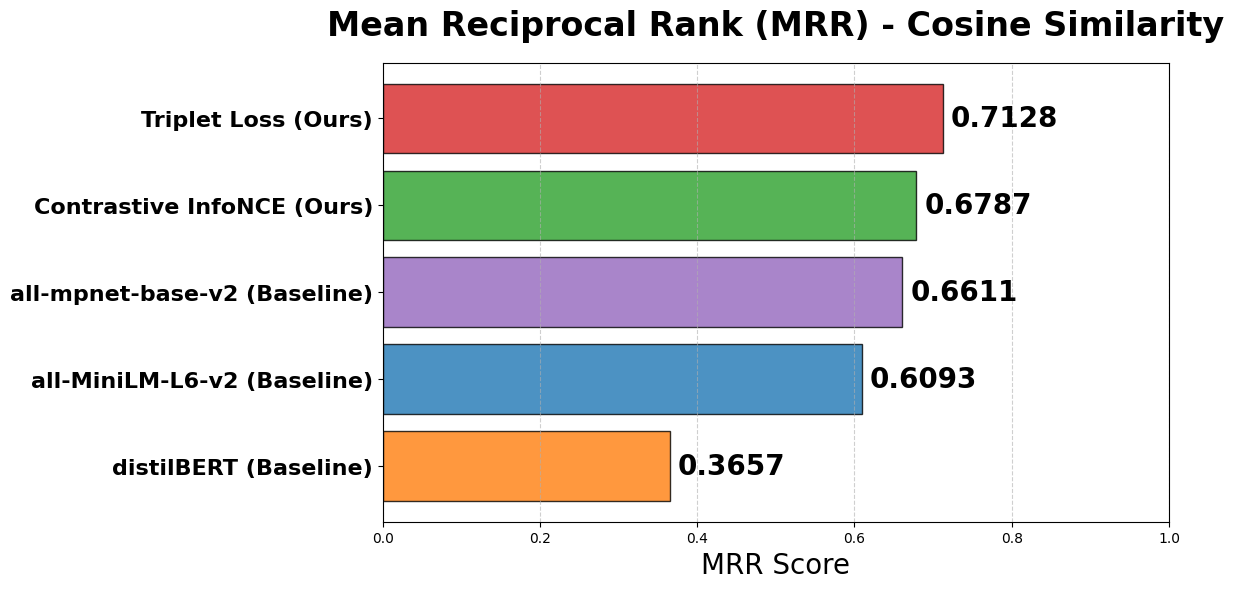

/tmp/ipykernel_580/3072383378.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(sorted_labels_cos, fontsize=16, fontweight='bold')


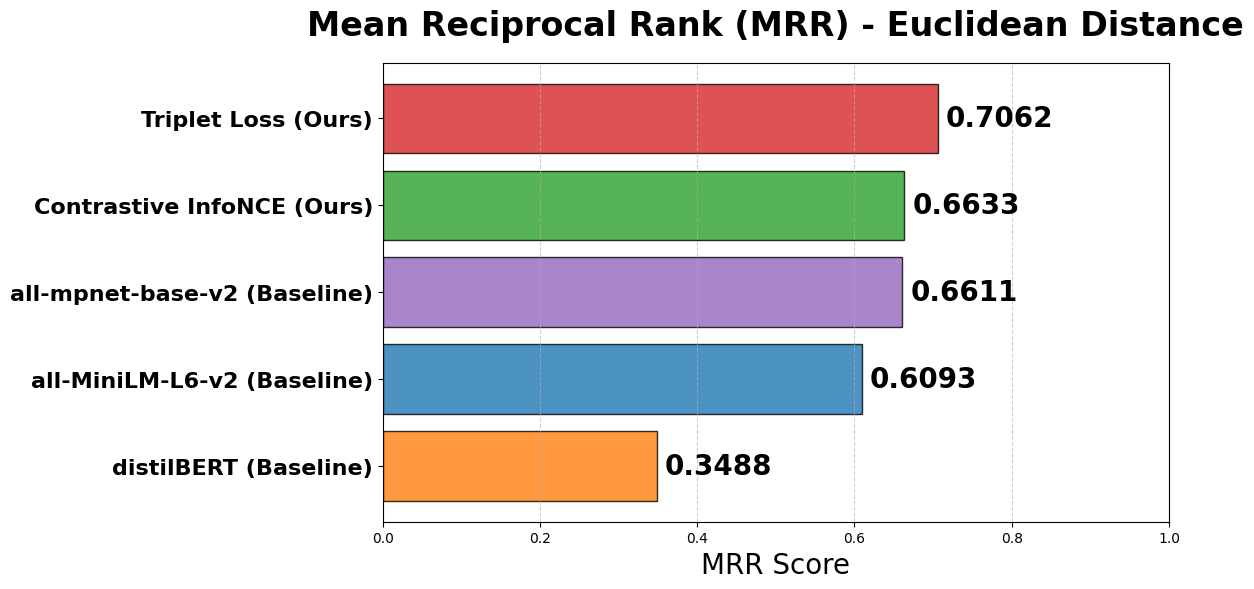

In [ ]:

labels_base = [
    'distilBERT (Baseline)',
    'all-MiniLM-L6-v2 (Baseline)',
    'all-mpnet-base-v2 (Baseline)',
    'Contrastive InfoNCE (Ours)',
    'Triplet Loss (Ours)'
]

values_cos = [
    mrr_distilBERT_cos,
    mrr_minilm_cos,
    mrr_mpnet_cos,
    mrr_contrastive_test_cos,
    mrr_triplet_test_cos
]

values_euc = [
    mrr_distilBERT_euc,
    mrr_minilm_euc,
    mrr_mpnet_euc,
    mrr_contrastive_test_euc,
    mrr_triplet_test_euc
]

colors_base = ['#ff7f0e', '#1f77b4', '#9467bd', '#2ca02c', '#d62728']

# --- COSINE SIMILARITY ---
fig1, ax1 = plt.subplots(figsize=(12, 6))

sorted_idx_cos = sorted(range(len(values_cos)), key=lambda i: values_cos[i])
sorted_labels_cos = [labels_base[i] for i in sorted_idx_cos]
sorted_values_cos = [values_cos[i] for i in sorted_idx_cos]
sorted_colors_cos = [colors_base[i] for i in sorted_idx_cos]

bars1 = ax1.barh(sorted_labels_cos, sorted_values_cos, color=sorted_colors_cos, edgecolor='black', alpha=0.8)
ax1.set_title('Mean Reciprocal Rank (MRR) - Cosine Similarity', fontsize=24, fontweight='bold', pad=20)
ax1.set_xlabel('MRR Score', fontsize=20)
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', linestyle='--', alpha=0.6)

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center', fontsize=20, fontweight='bold')

ax1.set_yticklabels(sorted_labels_cos, fontsize=16, fontweight='bold')
fig1.tight_layout()
fig1.savefig(plots_folder + 'mrr_cosine_final.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- EUCLIDEAN DISTANCE ---
fig2, ax2 = plt.subplots(figsize=(12, 6))

sorted_idx_euc = sorted(range(len(values_euc)), key=lambda i: values_euc[i])
sorted_labels_euc = [labels_base[i] for i in sorted_idx_euc]
sorted_values_euc = [values_euc[i] for i in sorted_idx_euc]
sorted_colors_euc = [colors_base[i] for i in sorted_idx_euc]

bars2 = ax2.barh(sorted_labels_euc, sorted_values_euc, color=sorted_colors_euc, edgecolor='black', alpha=0.8)
ax2.set_title('Mean Reciprocal Rank (MRR) - Euclidean Distance', fontsize=24, fontweight='bold', pad=20)
ax2.set_xlabel('MRR Score', fontsize=20)
ax2.set_xlim(0, 1.0)
ax2.grid(axis='x', linestyle='--', alpha=0.6)

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center', fontsize=20, fontweight='bold')

ax2.set_yticklabels(sorted_labels_cos, fontsize=16, fontweight='bold')
fig2.tight_layout()
fig2.savefig(plots_folder + 'mrr_euclidean_final.pdf', format='pdf', bbox_inches='tight')
plt.show()

# **Re Ranking**

## **Re Ranking Function**

In [ ]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)

def reranking(cross_encoder, initial_rankings, K, dataset, correct_rankings=True):

    re_rankings = []
    new_correct_ranks = []

    for i, (query, candidates) in enumerate(zip(dataset['query'], dataset['candidate_chunks'])):

        # Retrieve the rankings for that query
        initial_ranking = initial_rankings[i]

        # Taking only the top k candidates
        top_k_indices = initial_ranking[:K]
        remaining_indices = initial_ranking[K:]
        top_k_candidates = [candidates[idx] for idx in top_k_indices]

        # Creating the couples to match the CrossEncoder input format
        cross_encoder_inputs = [[query, candidate] for candidate in top_k_candidates]

        new_scores = cross_encoder.predict(cross_encoder_inputs, convert_to_tensor=True)

        # Ordering the new values
        sorted_score_indices = torch.argsort(new_scores, descending=True).tolist()
        resorted_top_k_indices = [top_k_indices[idx] for idx in sorted_score_indices]

        # Retrieving all the rankings
        final_ranking = resorted_top_k_indices + remaining_indices
        re_rankings.append(final_ranking)

        if correct_rankings:
            gold_pos = dataset['answer_pos'][i]
            correct_rank = final_ranking.index(gold_pos) + 1
            new_correct_ranks.append(correct_rank)

    return re_rankings, new_correct_ranks


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

## **Ranking Generation**

### **Re ranking on Test Set**

In [ ]:
# distilBERT base
distilBERT_rankings_from_cos, distilBERT_correct_ranks_from_cos = reranking(cross_encoder, distilBERT_rankings_cos, 10, test)
print("✅ DistilBERT (from Cosine) complete.\n")
distilBERT_rankings_from_euc, distilBERT_correct_ranks_from_euc = reranking(cross_encoder, distilBERT_rankings_euclidean, 10, test)
print("✅ DistilBERT (from Euclidean) complete.\n")

# All-miniLM
minilm_rankings_from_cos, minilm_correct_ranks_from_cos = reranking(cross_encoder, minilm_rankings_cos, 10, test)
print("✅ MiniLM (from Cosine) complete.\n")
minilm_rankings_from_euc, minilm_correct_ranks_from_euc = reranking(cross_encoder, minilm_rankings_euclidean, 10, test)
print("✅ MiniLM (from Euclidean) complete.\n")

# All-mpnet
mpnet_rankings_from_cos, mpnet_correct_ranks_from_cos = reranking(cross_encoder, mpnet_rankings_cos, 10, test)
print("✅ mpnet (from Cosine) complete.\n")
mpnet_rankings_from_euc, mpnet_correct_ranks_from_euc = reranking(cross_encoder, mpnet_rankings_euclidean, 10, test)
print("✅ mpnet (from Euclidean) complete.\n")

# CONTRASTIVE INFONCE
contrastive_rankings_from_cos, contrastive_correct_ranks_from_cos = reranking(cross_encoder, contrastive_fineTuned_rankings_cos, 10, test)
print("✅ Contrastive (from Cosine) complete.\n")
contrastive_rankings_from_euc, contrastive_correct_ranks_from_euc = reranking(cross_encoder, contrastive_fineTuned_rankings_euc, 10, test)
print("✅ Contrastive (from Euclidean) complete.\n")

# SENTENCE TRIPLET
triplet_rankings_from_cos, triplet_correct_ranks_from_cos = reranking(cross_encoder, triplet_fineTuned_rankings_cos, 10, test)
print("✅ Triplet (from Cosine) complete.\n")
triplet_rankings_from_euc, triplet_correct_ranks_from_euc = reranking(cross_encoder, triplet_fineTuned_rankings_euc, 10, test)
print("✅ Triplet (from Euclidean) complete.\n")




✅ DistilBERT (from Cosine) complete.

✅ DistilBERT (from Euclidean) complete.

✅ MiniLM (from Cosine) complete.

✅ MiniLM (from Euclidean) complete.

✅ mpnet (from Cosine) complete.

✅ mpnet (from Euclidean) complete.

✅ Contrastive (from Cosine) complete.

✅ Contrastive (from Euclidean) complete.

✅ Triplet (from Cosine) complete.

✅ Triplet (from Euclidean) complete.



### **Re ranking on Blind Set**

In [ ]:
# distilBERT base
distilBERT_rankings_from_cos_BLIND, _ = reranking(cross_encoder, distilBERT_rankings_cos_blind, 10, blind, correct_rankings=False)
print("✅ DistilBERT (from Cosine) complete.\n")
distilBERT_rankings_from_euc_BLIND, _ = reranking(cross_encoder, distilBERT_rankings_euc_blind, 10, blind, correct_rankings=False)
print("✅ DistilBERT (from Euclidean) complete.\n")

# All-miniLM
minilm_rankings_from_cos_BLIND, _ = reranking(cross_encoder, minilm_rankings_cos_blind, 10, blind, correct_rankings=False)
print("✅ MiniLM (from Cosine) complete.\n")
minilm_rankings_from_euc_BLIND, _ = reranking(cross_encoder, minilm_rankings_euc_blind, 10, blind, correct_rankings=False)
print("✅ MiniLM (from Euclidean) complete.\n")

# All-mpnet
mpnet_rankings_from_cos_BLIND, _ = reranking(cross_encoder, mpnet_rankings_cos_blind, 10, blind, correct_rankings=False)
print("✅ mpnet (from Cosine) complete.\n")
mpnet_rankings_from_euc_BLIND, _ = reranking(cross_encoder, mpnet_rankings_euc_blind, 10, blind, correct_rankings=False)
print("✅ mpnet (from Euclidean) complete.\n")

# CONTRASTIVE INFONCE
contrastive_rankings_from_cos_BLIND, _ = reranking(cross_encoder, contrastive_fineTuned_rankings_cos_blind, 10, blind, correct_rankings=False)
print("✅ Contrastive (from Cosine) complete.\n")
contrastive_rankings_from_euc_BLIND, _ = reranking(cross_encoder, contrastive_fineTuned_rankings_euc_blind, 10, blind, correct_rankings=False)
print("✅ Contrastive (from Euclidean) complete.\n")

# SENTENCE TRIPLET
triplet_rankings_from_cos_BLIND, _ = reranking(cross_encoder, triplet_fineTuned_rankings_cos_blind, 10, blind, correct_rankings=False)
print("✅ Triplet (from Cosine) complete.\n")
triplet_rankings_from_euc_BLIND, _ = reranking(cross_encoder, triplet_fineTuned_rankings_euc_blind, 10, blind, correct_rankings=False)
print("✅ Triplet (from Euclidean) complete.\n")




✅ DistilBERT (from Cosine) complete.

✅ DistilBERT (from Euclidean) complete.

✅ MiniLM (from Cosine) complete.

✅ MiniLM (from Euclidean) complete.

✅ mpnet (from Cosine) complete.

✅ mpnet (from Euclidean) complete.

✅ Contrastive (from Cosine) complete.

✅ Contrastive (from Euclidean) complete.

✅ Triplet (from Cosine) complete.

✅ Triplet (from Euclidean) complete.



# **Re ranking Evaluation**

## **Test**

### **Results (starting from rankings based on Cosine Similarity)**

In [ ]:
# distilBERT (Cosine) Metrics
hit_at_1_distilBERT  = hit_at_k_metric(len(test), 1, distilBERT_correct_ranks_from_cos)
hit_at_3_distilBERT  = hit_at_k_metric(len(test), 3, distilBERT_correct_ranks_from_cos)
hit_at_5_distilBERT  = hit_at_k_metric(len(test), 5, distilBERT_correct_ranks_from_cos)

# Compute MMR metric (Cosine Similarity)
mrr_distilBERT_cos = mrr_metric(distilBERT_correct_ranks_from_cos)

# All-MiniLM (Cosine) Metrics
hit_at_1_minilm  = hit_at_k_metric(len(test), 1, minilm_correct_ranks_from_cos)
hit_at_3_minilm  = hit_at_k_metric(len(test), 3, minilm_correct_ranks_from_cos)
hit_at_5_minilm  = hit_at_k_metric(len(test), 5, minilm_correct_ranks_from_cos)

mrr_minilm_cos = mrr_metric(minilm_correct_ranks_from_cos)

# All-mpnet (Cosine) Metrics
hit_at_1_mpnet  = hit_at_k_metric(len(test), 1, mpnet_correct_ranks_from_cos)
hit_at_3_mpnet  = hit_at_k_metric(len(test), 3, mpnet_correct_ranks_from_cos)
hit_at_5_mpnet  = hit_at_k_metric(len(test), 5, mpnet_correct_ranks_from_cos)

# Compute MMR metric (Cosine Similarity)
mrr_mpnet_cos = mrr_metric(mpnet_correct_ranks_from_cos)

# InfoNCE (Cosine) Metrics
hit_at_1_contrastive_test_cos  = hit_at_k_metric(len(test), 1, contrastive_correct_ranks_from_cos)
hit_at_3_contrastive_test_cos  = hit_at_k_metric(len(test), 3, contrastive_correct_ranks_from_cos)
hit_at_5_contrastive_test_cos  = hit_at_k_metric(len(test), 5, contrastive_correct_ranks_from_cos)

mrr_contrastive_test_cos = mrr_metric(contrastive_correct_ranks_from_cos)

# Triplets (Cosine) Metrics
hit_at_1_triplet_test_cos  = hit_at_k_metric(len(test), 1, triplet_correct_ranks_from_cos)
hit_at_3_triplet_test_cos  = hit_at_k_metric(len(test), 3, triplet_correct_ranks_from_cos)
hit_at_5_triplet_test_cos  = hit_at_k_metric(len(test), 5, triplet_correct_ranks_from_cos)

mrr_triplet_test_cos = mrr_metric(triplet_correct_ranks_from_cos)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5", "MRR"],
    "distilBERT test Results (Contrastive InfoNCE) (Cosine)": [hit_at_1_contrastive_test_cos, hit_at_3_contrastive_test_cos, hit_at_5_contrastive_test_cos, mrr_contrastive_test_cos],
    "distilBERT test Results (TripletLoss) (Cosine)": [hit_at_1_triplet_test_cos, hit_at_3_triplet_test_cos, hit_at_5_triplet_test_cos, mrr_triplet_test_cos],
    "distilBERT Results (Baseline) (Cosine)": [hit_at_1_distilBERT, hit_at_3_distilBERT, hit_at_5_distilBERT, mrr_distilBERT_cos],
    "all-MiniLM Results (Baseline) (Cosine)": [hit_at_1_minilm, hit_at_3_minilm, hit_at_5_minilm, mrr_minilm_cos],
    "all-mpnet Results (Baseline) (Cosine)": [hit_at_1_mpnet, hit_at_3_mpnet, hit_at_5_mpnet, mrr_mpnet_cos]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"distilBERT test Results (Contrastive InfoNCE) (Cosine)": "{:.4f}", "distilBERT test Results (TripletLoss) (Cosine)": "{:.4f}", "distilBERT Results (Baseline) (Cosine)": "{:.4f}",  "all-MiniLM Results (Baseline) (Cosine)": "{:.4f}", "all-mpnet Results (Baseline) (Cosine)": "{:.4f}"}))

Metric,distilBERT test Results (Contrastive InfoNCE) (Cosine),distilBERT test Results (TripletLoss) (Cosine),distilBERT Results (Baseline) (Cosine),all-MiniLM Results (Baseline) (Cosine),all-mpnet Results (Baseline) (Cosine)
Hit@1,0.5905,0.5900,0.5270,0.5895,0.5900
Hit@3,0.8110,0.8170,0.7105,0.8065,0.8135
Hit@5,0.8785,0.8840,0.7570,0.8645,0.8710
MRR,0.7194,0.7203,0.6376,0.7128,0.7171


### **Results (starting from rankings based on Euclidean Similarity)**

In [ ]:
# distilBERT (Euclidean) Metrics
hit_at_1_distilBERT_euc  = hit_at_k_metric(len(test), 1, distilBERT_correct_ranks_from_euc)
hit_at_3_distilBERT_euc  = hit_at_k_metric(len(test), 3, distilBERT_correct_ranks_from_euc)
hit_at_5_distilBERT_euc  = hit_at_k_metric(len(test), 5, distilBERT_correct_ranks_from_euc)

# Compute MMR metric (Euclidean Similarity)
mrr_distilBERT_euc = mrr_metric(distilBERT_correct_ranks_from_euc)

# All-MiniLM (Euclidean) Metrics
hit_at_1_minilm_euc  = hit_at_k_metric(len(test), 1, minilm_correct_ranks_from_euc)
hit_at_3_minilm_euc  = hit_at_k_metric(len(test), 3, minilm_correct_ranks_from_euc)
hit_at_5_minilm_euc  = hit_at_k_metric(len(test), 5, minilm_correct_ranks_from_euc)

mrr_minilm_euc = mrr_metric(minilm_correct_ranks_from_euc)

# All-mpnet (Euclidean) Metrics
hit_at_1_mpnet_euc  = hit_at_k_metric(len(test), 1, mpnet_correct_ranks_from_euc)
hit_at_3_mpnet_euc  = hit_at_k_metric(len(test), 3, mpnet_correct_ranks_from_euc)
hit_at_5_mpnet_euc  = hit_at_k_metric(len(test), 5, mpnet_correct_ranks_from_euc)

# Compute MMR metric (Euclidean Similarity)
mrr_mpnet_euc = mrr_metric(mpnet_correct_ranks_from_euc)

# InfoNCE (Euclidean) Metrics
hit_at_1_contrastive_test_euc  = hit_at_k_metric(len(test), 1, contrastive_correct_ranks_from_euc)
hit_at_3_contrastive_test_euc  = hit_at_k_metric(len(test), 3, contrastive_correct_ranks_from_euc)
hit_at_5_contrastive_test_euc  = hit_at_k_metric(len(test), 5, contrastive_correct_ranks_from_euc)

mrr_contrastive_test_euc = mrr_metric(contrastive_correct_ranks_from_euc)

# Triplets (Euclidean) Metrics
hit_at_1_triplet_test_euc  = hit_at_k_metric(len(test), 1, triplet_correct_ranks_from_euc)
hit_at_3_triplet_test_euc  = hit_at_k_metric(len(test), 3, triplet_correct_ranks_from_euc)
hit_at_5_triplet_test_euc  = hit_at_k_metric(len(test), 5, triplet_correct_ranks_from_euc)

mrr_triplet_test_euc = mrr_metric(triplet_correct_ranks_from_euc)

# Display the results in a fancy way
data = {
    "Metric": ["Hit@1", "Hit@3", "Hit@5", "MRR"],
    "distilBERT test Results (Contrastive InfoNCE) (Euclidean)": [hit_at_1_contrastive_test_euc, hit_at_3_contrastive_test_euc, hit_at_5_contrastive_test_euc, mrr_contrastive_test_euc],
    "distilBERT test Results (TripletLoss) (Euclidean)": [hit_at_1_triplet_test_euc, hit_at_3_triplet_test_euc, hit_at_5_triplet_test_euc, mrr_triplet_test_euc],
    "distilBERT Results (Baseline) (Euclidean)": [hit_at_1_distilBERT_euc, hit_at_3_distilBERT_euc, hit_at_5_distilBERT_euc, mrr_distilBERT_euc],
    "all-MiniLM Results (Baseline) (Euclidean)": [hit_at_1_minilm_euc, hit_at_3_minilm_euc, hit_at_5_minilm_euc, mrr_minilm_euc],
    "all-mpnet Results (Baseline) (Euclidean)": [hit_at_1_mpnet_euc, hit_at_3_mpnet_euc, hit_at_5_mpnet_euc, mrr_mpnet_euc]
}

df_results = pd.DataFrame(data)
display(df_results.style.hide(axis='index').format({"distilBERT test Results (Contrastive InfoNCE) (Euclidean)": "{:.4f}", "distilBERT test Results (TripletLoss) (Euclidean)": "{:.4f}", "distilBERT Results (Baseline) (Euclidean)": "{:.4f}",  "all-MiniLM Results (Baseline) (Euclidean)": "{:.4f}", "all-mpnet Results (Baseline) (Euclidean)": "{:.4f}"}))

Metric,distilBERT test Results (Contrastive InfoNCE) (Euclidean),distilBERT test Results (TripletLoss) (Euclidean),distilBERT Results (Baseline) (Euclidean),all-MiniLM Results (Baseline) (Euclidean),all-mpnet Results (Baseline) (Euclidean)
Hit@1,0.5905,0.5970,0.5070,0.5895,0.5900
Hit@3,0.8100,0.8235,0.6825,0.8065,0.8135
Hit@5,0.8770,0.8880,0.7305,0.8645,0.8710
MRR,0.7183,0.7257,0.6161,0.7128,0.7171


# **JSON File Creation**

In [ ]:
# Cosine Similarity file saving
tasks_cosine = [
    (test['query_id'], distilBERT_rankings_from_cos, "hit_k_1-test-distilbert-base-cosine_(reranking).jsonl"),
    (blind['query_id'], distilBERT_rankings_from_cos_BLIND, "hit_k_1-blind-distilbert-base-cosine_(reranking).jsonl"),
    (test['query_id'], minilm_rankings_from_cos, "hit_k_1-test-AllMini-base-cosine_(reranking).jsonl"),
    (blind['query_id'], minilm_rankings_from_cos_BLIND, "hit_k_1-blind-AllMini-base-cosine_(reranking).jsonl"),
    (test['query_id'], mpnet_rankings_from_cos, "hit_k_1-test-mpnet-base-cosine_(reranking).jsonl"),
    (blind['query_id'], mpnet_rankings_from_cos_BLIND, "hit_k_1-blind-mpnet-base-cosine_(reranking).jsonl"),
    (test['query_id'], contrastive_rankings_from_cos, "hit_k_1-test-distilbert-contrastive-cosine_(reranking).jsonl"),
    (blind['query_id'], contrastive_rankings_from_cos_BLIND, "hit_k_1-blind-distilbert-contrastive-cosine_(reranking).jsonl"),
    (test['query_id'], triplet_rankings_from_cos, "hit_k_1-test-distilbert-triplet-cosine_(reranking).jsonl"),
    (blind['query_id'], triplet_rankings_from_cos_BLIND, "hit_k_1-blind-distilbert-triplet-cosine_(reranking).jsonl"),
]

for ids, rankings, name in tasks_cosine:
    save_jsonl(ids, rankings, name, output_folder)

# Euclidean Similarity file saving
tasks_euclidean = [
    (test['query_id'], distilBERT_rankings_from_euc, "hit_k_1-test-distilbert-base-euclidean_(reranking).jsonl"),
    (blind['query_id'], distilBERT_rankings_from_euc_BLIND, "hit_k_1-blind-distilbert-base-euclidean_(reranking).jsonl"),
    (test['query_id'], minilm_rankings_from_euc, "hit_k_1-test-AllMini-base-euclidean_(reranking).jsonl"),
    (blind['query_id'], minilm_rankings_from_euc_BLIND, "hit_k_1-blind-AllMini-base-euclidean_(reranking).jsonl"),
    (test['query_id'], mpnet_rankings_from_euc, "hit_k_1-test-mpnet-base-euclidean_(reranking).jsonl"),
    (blind['query_id'], mpnet_rankings_from_euc_BLIND, "hit_k_1-blind-mpnet-base-euclidean_(reranking).jsonl"),
    (test['query_id'], contrastive_rankings_from_euc, "hit_k_1-test-distilbert-contrastive-euclidean_(reranking).jsonl"),
    (blind['query_id'], contrastive_rankings_from_euc_BLIND, "hit_k_1-blind-distilbert-contrastive-euclidean_(reranking).jsonl"),
    (test['query_id'], triplet_rankings_from_euc, "hit_k_1-test-distilbert-triplet-euclidean_(reranking).jsonl"),
    (blind['query_id'], triplet_rankings_from_euc_BLIND, "hit_k_1-blind-distilbert-triplet-euclidean_(reranking).jsonl"),
]

for ids, rankings, name in tasks_euclidean:
    save_jsonl(ids, rankings, name, output_folder)

File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-distilbert-base-cosine_(reranking).jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-distilbert-base-cosine_(reranking).jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-AllMini-base-cosine_(reranking).jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-AllMini-base-cosine_(reranking).jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-mpnet-base-cosine_(reranking).jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-mpnet-base-cosine_(reranking).jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-test-distilbert-contrastive-cosine_(reranking).jsonl
File saved: /content/drive/MyDrive/MNLP_2026_HW1_2278125_2283937/outputs/hit_k_1-blind-distilbert-contrastive-cosine_

# **Plots Area**

## **Hit@k Comparison**

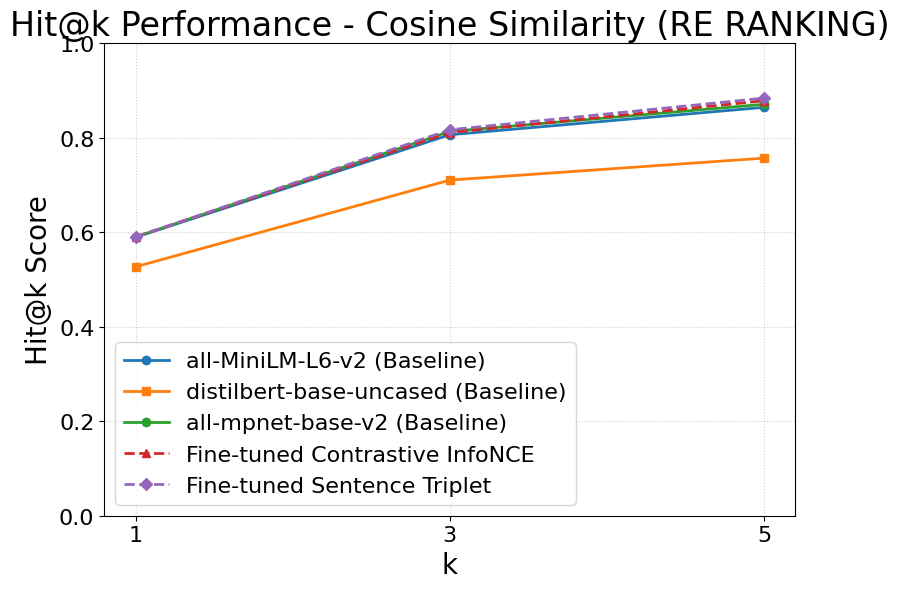

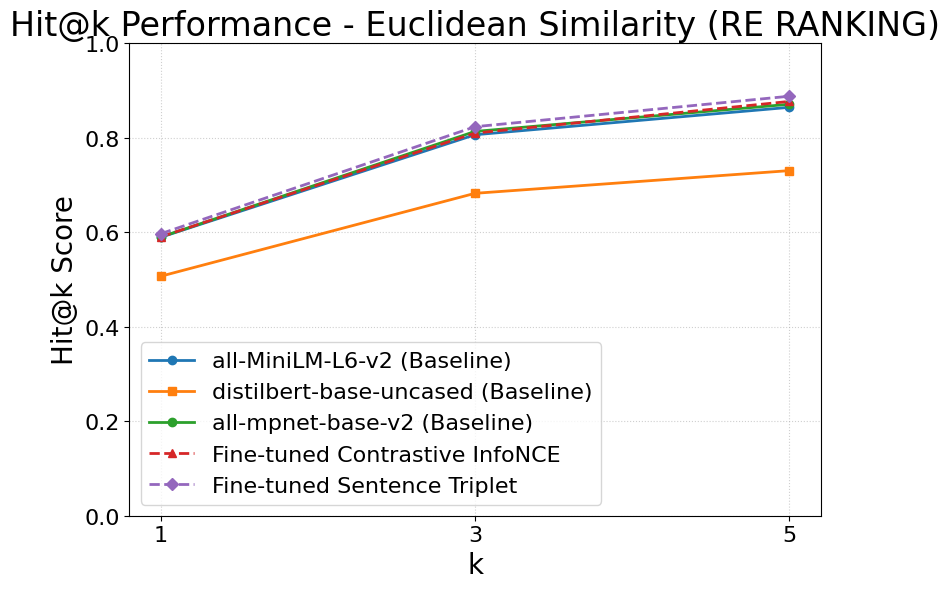

In [ ]:
# Values for k-axis
k_values = [1, 3, 5]

# --- (COSINE SIMILARITY) ---
# Baselines
y_minilm_cos = [hit_at_1_minilm, hit_at_3_minilm, hit_at_5_minilm]
y_distil_cos = [hit_at_1_distilBERT, hit_at_3_distilBERT, hit_at_5_distilBERT]
y_mpnet_cos = [hit_at_1_mpnet, hit_at_3_mpnet, hit_at_5_mpnet]

# Fine-tuned
y_contrastive_cos = [hit_at_1_contrastive_test_cos, hit_at_3_contrastive_test_cos, hit_at_5_contrastive_test_cos]
y_triplet_cos = [hit_at_1_triplet_test_cos, hit_at_3_triplet_test_cos, hit_at_5_triplet_test_cos]

# --- (EUCLIDEAN SIMILARITY) ---
# Baselines
y_minilm_euc = [hit_at_1_minilm_euc, hit_at_3_minilm_euc, hit_at_5_minilm_euc]
y_distil_euc = [hit_at_1_distilBERT_euc, hit_at_3_distilBERT_euc, hit_at_5_distilBERT_euc]
y_mpnet_euc = [hit_at_1_mpnet_euc, hit_at_3_mpnet_euc, hit_at_5_mpnet_euc]

# Fine-tuned
y_contrastive_euc = [hit_at_1_contrastive_test_euc, hit_at_3_contrastive_test_euc, hit_at_5_contrastive_test_euc]
y_triplet_euc = [hit_at_1_triplet_test_euc, hit_at_3_triplet_test_euc, hit_at_5_triplet_test_euc]

# --- PLOT 1: COSINE SIMILARITY ---
fig1, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_values, y_minilm_cos, marker='o', linestyle='-', linewidth=2, label='all-MiniLM-L6-v2 (Baseline)')
ax1.plot(k_values, y_distil_cos, marker='s', linestyle='-', linewidth=2, label='distilbert-base-uncased (Baseline)')
ax1.plot(k_values, y_mpnet_cos, marker='o', linestyle='-', linewidth=2, label='all-mpnet-base-v2 (Baseline)')
ax1.plot(k_values, y_contrastive_cos, marker='^', linestyle='--', linewidth=2, label='Fine-tuned Contrastive InfoNCE')
ax1.plot(k_values, y_triplet_cos, marker='D', linestyle='--', linewidth=2, label='Fine-tuned Sentence Triplet')

ax1.set_title('Hit@k Performance - Cosine Similarity (RE RANKING)', fontsize=24)
ax1.set_xlabel('k', fontsize=20)
ax1.set_ylabel('Hit@k Score', fontsize=20)
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1.0)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=16)

ax1.tick_params(axis='both', which='major', labelsize=16)
fig1.tight_layout()
fig1.savefig(plots_folder + 'hit_at_k_cosine_reranking.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- PLOT 2: EUCLIDEAN SIMILARITY ---
fig2, ax2 = plt.subplots(figsize=(8, 6))

ax2.plot(k_values, y_minilm_euc, marker='o', linestyle='-', linewidth=2, label='all-MiniLM-L6-v2 (Baseline)')
ax2.plot(k_values, y_distil_euc, marker='s', linestyle='-', linewidth=2, label='distilbert-base-uncased (Baseline)')
ax2.plot(k_values, y_mpnet_euc, marker='o', linestyle='-', linewidth=2, label='all-mpnet-base-v2 (Baseline)')
ax2.plot(k_values, y_contrastive_euc, marker='^', linestyle='--', linewidth=2, label='Fine-tuned Contrastive InfoNCE')
ax2.plot(k_values, y_triplet_euc, marker='D', linestyle='--', linewidth=2, label='Fine-tuned Sentence Triplet')

ax2.set_title('Hit@k Performance - Euclidean Similarity (RE RANKING)', fontsize=24)
ax2.set_xlabel('k', fontsize=20)
ax2.set_ylabel('Hit@k Score', fontsize=20)
ax2.set_xticks(k_values)
ax2.set_ylim(0, 1.0)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=16)

ax2.tick_params(axis='both', which='major', labelsize=16)
fig2.tight_layout()
fig2.savefig(plots_folder + 'hit_at_k_euclidean_reranking.pdf', format='pdf', bbox_inches='tight')
plt.show()

## **MRR Comparison**

In [ ]:

labels_base = [
    'distilBERT (Baseline)',
    'all-MiniLM-L6-v2 (Baseline)',
    'all-mpnet-base-v2 (Baseline)',
    'Contrastive InfoNCE (Ours)',
    'Triplet Loss (Ours)'
]

values_cos = [
    mrr_distilBERT_cos,
    mrr_minilm_cos,
    mrr_mpnet_cos,
    mrr_contrastive_test_cos,
    mrr_triplet_test_cos
]

values_euc = [
    mrr_distilBERT_euc,
    mrr_minilm_euc,
    mrr_mpnet_euc,
    mrr_contrastive_test_euc,
    mrr_triplet_test_euc
]

colors_base = ['#ff7f0e', '#1f77b4', '#9467bd', '#2ca02c', '#d62728']

# --- COSINE SIMILARITY ---
fig1, ax1 = plt.subplots(figsize=(12, 6))

sorted_idx_cos = sorted(range(len(values_cos)), key=lambda i: values_cos[i])
sorted_labels_cos = [labels_base[i] for i in sorted_idx_cos]
sorted_values_cos = [values_cos[i] for i in sorted_idx_cos]
sorted_colors_cos = [colors_base[i] for i in sorted_idx_cos]

bars1 = ax1.barh(sorted_labels_cos, sorted_values_cos, color=sorted_colors_cos, edgecolor='black', alpha=0.8)
ax1.set_title('Mean Reciprocal Rank (MRR) (RE RANKING) - Cosine Similarity', fontsize=24, fontweight='bold', pad=20)
ax1.set_xlabel('MRR Score', fontsize=20)
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', linestyle='--', alpha=0.6)

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center', fontsize=20, fontweight='bold')

ax1.set_yticklabels(sorted_labels_cos, fontsize=16, fontweight='bold')
fig1.tight_layout()
fig1.savefig(plots_folder + 'mrr_cosine_final_reranking.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- EUCLIDEAN DISTANCE ---
fig2, ax2 = plt.subplots(figsize=(12, 6))

sorted_idx_euc = sorted(range(len(values_euc)), key=lambda i: values_euc[i])
sorted_labels_euc = [labels_base[i] for i in sorted_idx_euc]
sorted_values_euc = [values_euc[i] for i in sorted_idx_euc]
sorted_colors_euc = [colors_base[i] for i in sorted_idx_euc]

bars2 = ax2.barh(sorted_labels_euc, sorted_values_euc, color=sorted_colors_euc, edgecolor='black', alpha=0.8)
ax2.set_title('Mean Reciprocal Rank (MRR) (RE RANKING) - Euclidean Distance', fontsize=24, fontweight='bold', pad=20)
ax2.set_xlabel('MRR Score', fontsize=20)
ax2.set_xlim(0, 1.0)
ax2.grid(axis='x', linestyle='--', alpha=0.6)

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center', fontsize=20, fontweight='bold')

ax2.set_yticklabels(sorted_labels_cos, fontsize=16, fontweight='bold')
fig2.tight_layout()
fig2.savefig(plots_folder + 'mrr_euclidean_final_reranking.pdf', format='pdf', bbox_inches='tight')
plt.show()